<a href="https://colab.research.google.com/github/HakumenWorld/Digital-Skola/blob/main/%5BFebi_Kristiana_DS_Batch_60%5DData_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5 – Data Visualization With Python  


Buatlah visualisasi dengan menggunakan python (library matplotlib/seaborn) dari berbagai kolom/variable sesuai perintah berikut:

1.	[50 poin] Buatlah 5 visualisasi untuk kolom attrition_flag, customer_age, gender, education_level, dan income_category. Satu kolom satu visualisasi saja. Wajib ada pie chart, donut chart, vertical bar chart, dan horizontal bar chart (pilih salah satu chart untuk suatu kolom).

2.	[5 poin] Tuliskan informasi/insight dari setiap visualisasi yang dibuat untuk No. 1.

3.	[10 poin] Buatlah 1 visualisasi menggunakan countplot yang memadukan lebih dari satu kolom (bebas antar kolom yang mana saja).

4.	[10 poin] Buatlah 1 visualisasi menggunakan scatterplot yang memadukan lebih dari satu kolom (bebas antar kolom yang mana saja, pastikan kolom sumbu x dan y bertipe numerikal).

5.	[10 poin] Buatlah 1 visualisasi menggunakan heatmap yang memadukan lebih dari satu kolom untuk menunjukkan nilai korelasi antar kolom tersebut (bebas antar kolom yang mana saja).

6.	[15 poin] Tuliskan insight dari setiap visualisasi yang dibuat untuk No. 3-5.


## 1. Import Library

Bagian ini digunakan untuk memanggil library yang diperlukan.

- `pandas` digunakan untuk membaca dan mengolah dataset.
- `numpy` digunakan untuk operasi numerik sederhana.
- `matplotlib.pyplot` digunakan untuk membuat visualisasi dasar seperti pie chart, donut chart, bar chart, dan histogram.
- `seaborn` digunakan untuk visualisasi statistik seperti countplot, scatterplot, dan heatmap.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur ukuran default grafik agar lebih nyaman dilihat
plt.rcParams['figure.figsize'] = (8, 5)

# Mengatur style visualisasi seaborn
sns.set_theme(style='whitegrid')

## 2. Load Dataset



In [14]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset dari Google Drive
file_path = '/content/drive/MyDrive/Digital Skola/BankChurners.csv'
df = pd.read_csv(file_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 3. Mengecek Struktur Data

Kode berikut digunakan untuk melihat jumlah baris, jumlah kolom, tipe data, dan apakah terdapat missing value.

In [15]:
# Melihat ukuran dataset
print('Jumlah baris dan kolom:', df.shape)

# Melihat daftar nama kolom
print('\nDaftar kolom:')
print(df.columns)

# Melihat informasi tipe data
print('\nInformasi dataset:')
df.info()

# Mengecek jumlah missing value di setiap kolom
print('\nMissing value setiap kolom:')
print(df.isnull().sum())

Jumlah baris dan kolom: (10127, 23)

Daftar kolom:
Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                          

## 4. Ringkasan Data Kolom yang Digunakan

Kode ini membantu melihat distribusi awal dari kolom-kolom yang akan divisualisasikan.

In [17]:
kolom_visualisasi = ['Attrition_Flag', 'Customer_Age', 'Gender', 'Education_Level', 'Income_Category']

for kolom in kolom_visualisasi:
    print('\n==============================')
    print('Kolom:', kolom)
    print(df[kolom].value_counts())


Kolom: Attrition_Flag
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Kolom: Customer_Age
Customer_Age
44    500
49    495
46    490
45    486
47    479
43    473
48    472
50    452
42    426
51    398
53    387
41    379
52    376
40    361
39    333
54    307
38    303
55    279
56    262
37    260
57    223
36    221
35    184
58    157
59    157
34    146
60    127
33    127
32    106
65    101
61     93
62     93
31     91
26     78
30     70
63     65
29     56
64     43
27     32
28     29
67      4
66      2
68      2
70      1
73      1
Name: count, dtype: int64

Kolom: Gender
Gender
F    5358
M    4769
Name: count, dtype: int64

Kolom: Education_Level
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

Kolom: Income_Category
Income_Category
Less than $40K    3561
$40K - $60K       1790


# No. 1 – Lima Visualisasi untuk Kolom yang Ditentukan

## Visualisasi 1: Pie Chart untuk `Attrition_Flag`

Pie chart cocok digunakan untuk melihat proporsi antara nasabah yang masih aktif dan nasabah yang sudah churn/attrited.

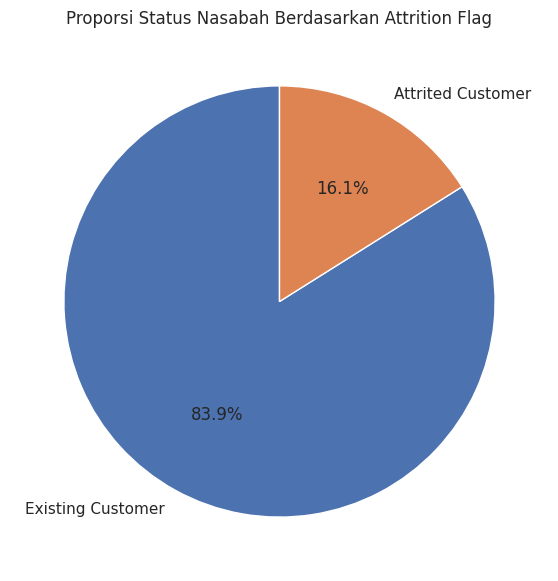

In [19]:
# Menghitung jumlah data berdasarkan Attrition_Flag
attrition_counts = df['Attrition_Flag'].value_counts()

# Membuat pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proporsi Status Nasabah Berdasarkan Attrition Flag')
plt.show()

**Insight Visualisasi 1:**  
Mayoritas nasabah dalam dataset masih termasuk kategori **Existing Customer**. Berdasarkan data, terdapat **8.500 Existing Customer** atau sekitar **83,93%**, sedangkan **Attrited Customer** berjumlah **1.627** atau sekitar **16,07%**. Hal ini menunjukkan bahwa proporsi nasabah yang berhenti menggunakan layanan lebih kecil dibandingkan nasabah yang masih aktif.

## Visualisasi 2: Histogram untuk `Customer_Age`

Kolom `Customer_Age` bertipe numerik, sehingga histogram lebih tepat digunakan untuk melihat sebaran usia nasabah.

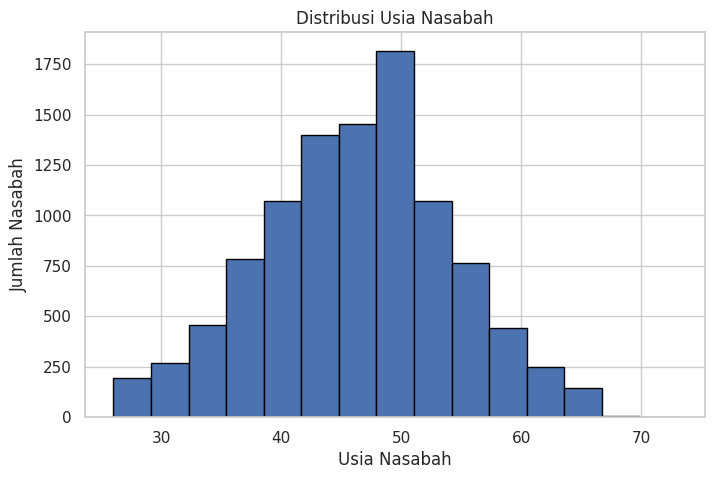

In [21]:
# Membuat histogram untuk 'Customer_Age'
plt.figure(figsize=(8, 5))
plt.hist(df['Customer_Age'], bins=15, edgecolor='black')

plt.title('Distribusi Usia Nasabah')
plt.xlabel('Usia Nasabah')
plt.ylabel('Jumlah Nasabah')
plt.show()

**Insight Visualisasi 2:**  
Usia nasabah paling banyak berada pada rentang **40–50 tahun**. Rata-rata usia nasabah adalah sekitar **46,33 tahun**, dengan usia minimum **26 tahun** dan maksimum **73 tahun**. Artinya, pengguna kartu kredit dalam dataset ini didominasi oleh kelompok usia dewasa menengah.

## Visualisasi 3: Donut Chart untuk `Gender`

Donut chart digunakan untuk memperlihatkan proporsi jumlah nasabah berdasarkan jenis kelamin.

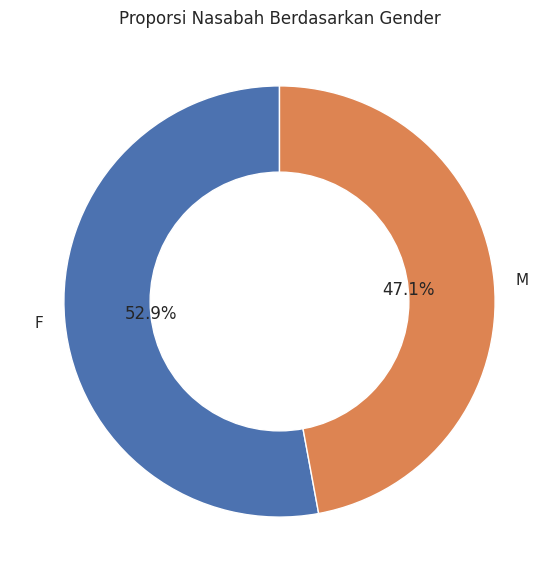

In [22]:
# Menghitung jumlah data berdasarkan Gender
gender_counts = df['Gender'].value_counts()

# Membuat donut chart
plt.figure(figsize=(7, 7))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

# Membuat lingkaran putih di tengah agar menjadi donut chart
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporsi Nasabah Berdasarkan Gender')
plt.show()

**Insight Visualisasi 3:**  
Jumlah nasabah perempuan sedikit lebih banyak dibandingkan laki-laki. Nasabah perempuan berjumlah **5.358 orang** atau sekitar **52,91%**, sedangkan nasabah laki-laki berjumlah **4.769 orang** atau sekitar **47,09%**. Perbedaannya tidak terlalu besar, sehingga distribusi gender relatif seimbang.

## Visualisasi 4: Vertical Bar Chart untuk `Education_Level`

Vertical bar chart digunakan untuk membandingkan jumlah nasabah pada setiap tingkat pendidikan.

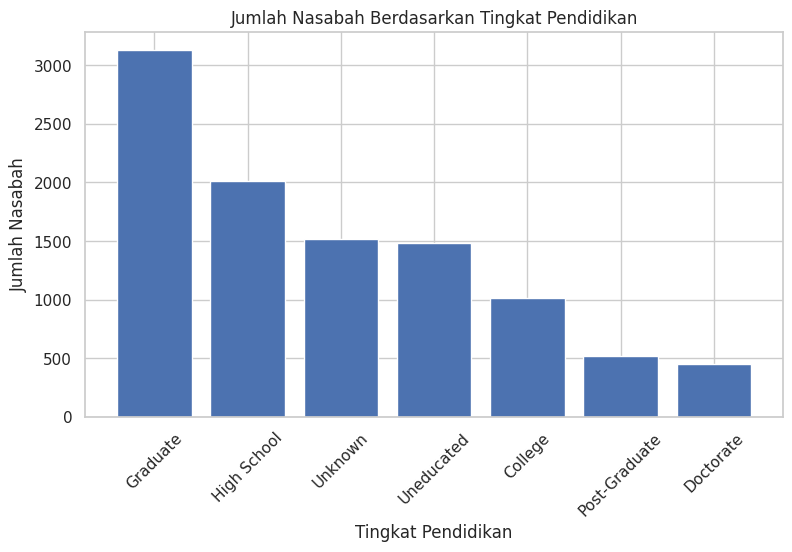

In [23]:
# Menghitung jumlah data berdasarkan Education_Level
education_counts = df['Education_Level'].value_counts()

# Membuat vertical bar chart
plt.figure(figsize=(9, 5))
plt.bar(education_counts.index, education_counts.values)

plt.title('Jumlah Nasabah Berdasarkan Tingkat Pendidikan')
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Jumlah Nasabah')
plt.xticks(rotation=45)
plt.show()

**Insight Visualisasi 4:**  
Kategori pendidikan terbanyak adalah **Graduate** dengan jumlah **3.128 nasabah** atau sekitar **30,89%**. Setelah itu diikuti oleh **High School** sebanyak **2.013 nasabah**. Terdapat juga kategori **Unknown** sebanyak **1.519 nasabah**, sehingga sebagian data pendidikan belum teridentifikasi secara jelas.

## Visualisasi 5: Horizontal Bar Chart untuk `Income_Category`

Horizontal bar chart cocok digunakan karena nama kategori pendapatan relatif panjang, sehingga lebih mudah dibaca secara horizontal.

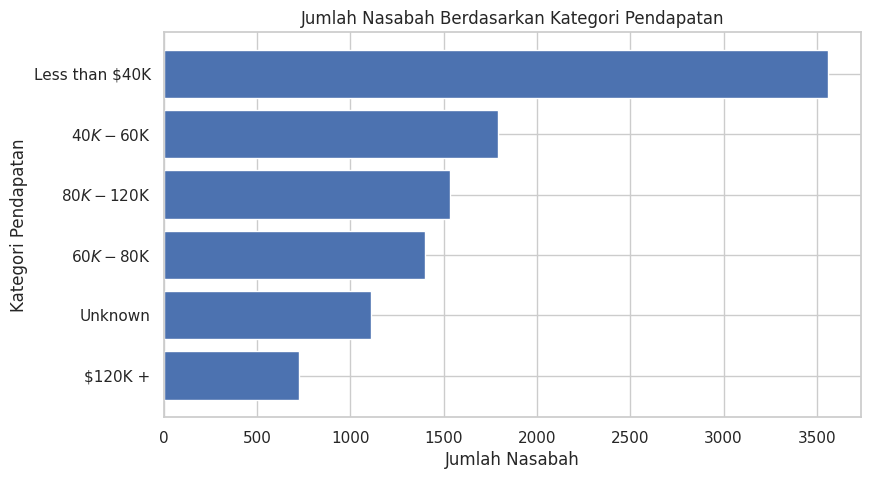

In [24]:
# Menghitung jumlah data berdasarkan Income_Category
income_counts = df['Income_Category'].value_counts()

# Membuat horizontal bar chart
plt.figure(figsize=(9, 5))
plt.barh(income_counts.index, income_counts.values)

plt.title('Jumlah Nasabah Berdasarkan Kategori Pendapatan')
plt.xlabel('Jumlah Nasabah')
plt.ylabel('Kategori Pendapatan')
plt.gca().invert_yaxis()
plt.show()

**Insight Visualisasi 5:**  
Kategori pendapatan terbesar adalah **Less than $40K** dengan jumlah **3.561 nasabah** atau sekitar **35,16%**. Kategori ini menunjukkan bahwa sebagian besar nasabah berada pada kelompok pendapatan rendah hingga menengah. Sementara itu, kategori **$120K+** merupakan kelompok paling sedikit, yaitu **727 nasabah** atau sekitar **7,18%**.

# No. 3 – Countplot yang Memadukan Lebih dari Satu Kolom

## Visualisasi 6: Countplot `Gender` dan `Attrition_Flag`

Countplot ini digunakan untuk membandingkan jumlah nasabah aktif dan attrited berdasarkan gender.

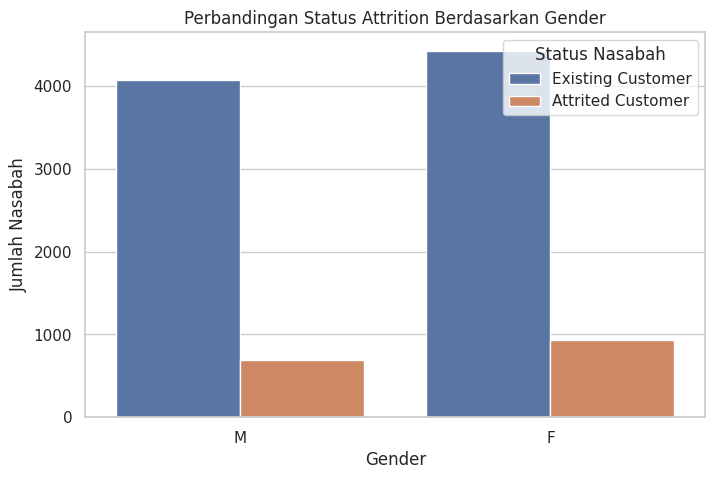

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Gender',
    hue='Attrition_Flag'
)

plt.title('Perbandingan Status Attrition Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah Nasabah')
plt.legend(title='Status Nasabah')
plt.show()

In [26]:
# Tabel pendukung untuk menghitung jumlah dan persentase attrition berdasarkan gender
gender_attrition_table = pd.crosstab(df['Gender'], df['Attrition_Flag'])
gender_attrition_percentage = pd.crosstab(df['Gender'], df['Attrition_Flag'], normalize='index') * 100

print('Jumlah nasabah berdasarkan Gender dan Attrition Flag:')
print(gender_attrition_table)

print('\nPersentase berdasarkan Gender:')
print(gender_attrition_percentage.round(2))

Jumlah nasabah berdasarkan Gender dan Attrition Flag:
Attrition_Flag  Attrited Customer  Existing Customer
Gender                                              
F                             930               4428
M                             697               4072

Persentase berdasarkan Gender:
Attrition_Flag  Attrited Customer  Existing Customer
Gender                                              
F                           17.36              82.64
M                           14.62              85.38


**Insight Visualisasi 6:**  
Pada kedua kelompok gender, jumlah **Existing Customer** lebih tinggi dibandingkan **Attrited Customer**. Namun, persentase attrited pada nasabah perempuan sekitar **17,36%**, sedikit lebih tinggi dibandingkan laki-laki yang sekitar **14,62%**. Hal ini dapat menjadi sinyal awal bahwa kelompok perempuan dalam dataset memiliki tingkat churn yang sedikit lebih tinggi, meskipun perlu analisis lanjutan untuk mengetahui penyebabnya.

# No. 4 – Scatterplot yang Memadukan Lebih dari Satu Kolom Numerik

## Visualisasi 7: Scatterplot `Total_Trans_Amt` dan `Total_Trans_Ct`

Scatterplot ini digunakan untuk melihat hubungan antara total nilai transaksi dan jumlah transaksi.  
Kedua kolom tersebut bertipe numerik, sehingga memenuhi syarat untuk scatterplot.

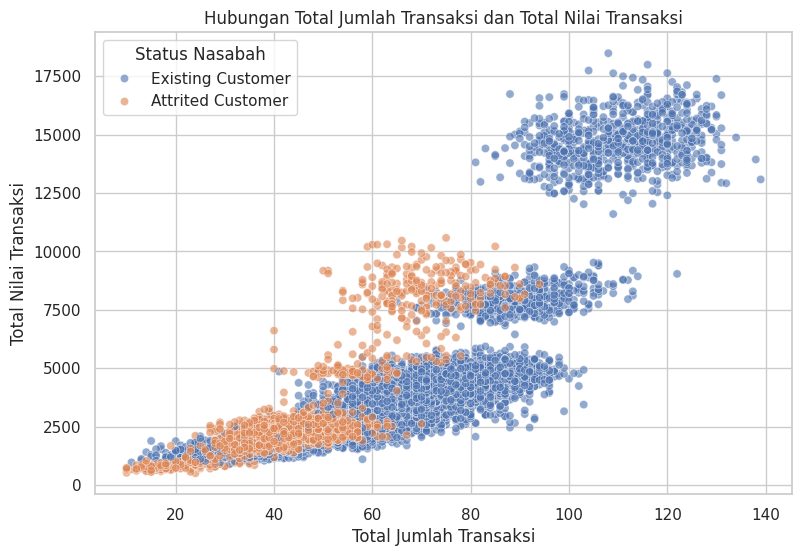

In [27]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Total_Trans_Ct',
    y='Total_Trans_Amt',
    hue='Attrition_Flag',
    alpha=0.6
)

plt.title('Hubungan Total Jumlah Transaksi dan Total Nilai Transaksi')
plt.xlabel('Total Jumlah Transaksi')
plt.ylabel('Total Nilai Transaksi')
plt.legend(title='Status Nasabah')
plt.show()

In [28]:
# Menghitung korelasi antara Total_Trans_Ct dan Total_Trans_Amt
correlation_transaction = df[['Total_Trans_Ct', 'Total_Trans_Amt']].corr()
correlation_transaction

,Total_Trans_Ct,Total_Trans_Amt
Total_Trans_Ct,1.000000,0.807192
Total_Trans_Amt,0.807192,1.000000


**Insight Visualisasi 7:**  
Terdapat hubungan positif yang kuat antara **Total_Trans_Ct** dan **Total_Trans_Amt**. Nilai korelasinya sekitar **0,807**, sehingga semakin banyak jumlah transaksi yang dilakukan nasabah, semakin besar pula total nilai transaksinya. Dari visualisasi, nasabah yang attrited cenderung lebih banyak berada pada area transaksi yang lebih rendah dibandingkan existing customer.

# No. 5 – Heatmap Korelasi Antar Kolom Numerik

## Visualisasi 8: Heatmap Korelasi

Heatmap digunakan untuk melihat tingkat hubungan antar beberapa kolom numerik.  
Kolom `CLIENTNUM` dan dua kolom `Naive_Bayes_Classifier...` tidak digunakan karena bukan variabel perilaku utama nasabah dan dapat mengganggu interpretasi.

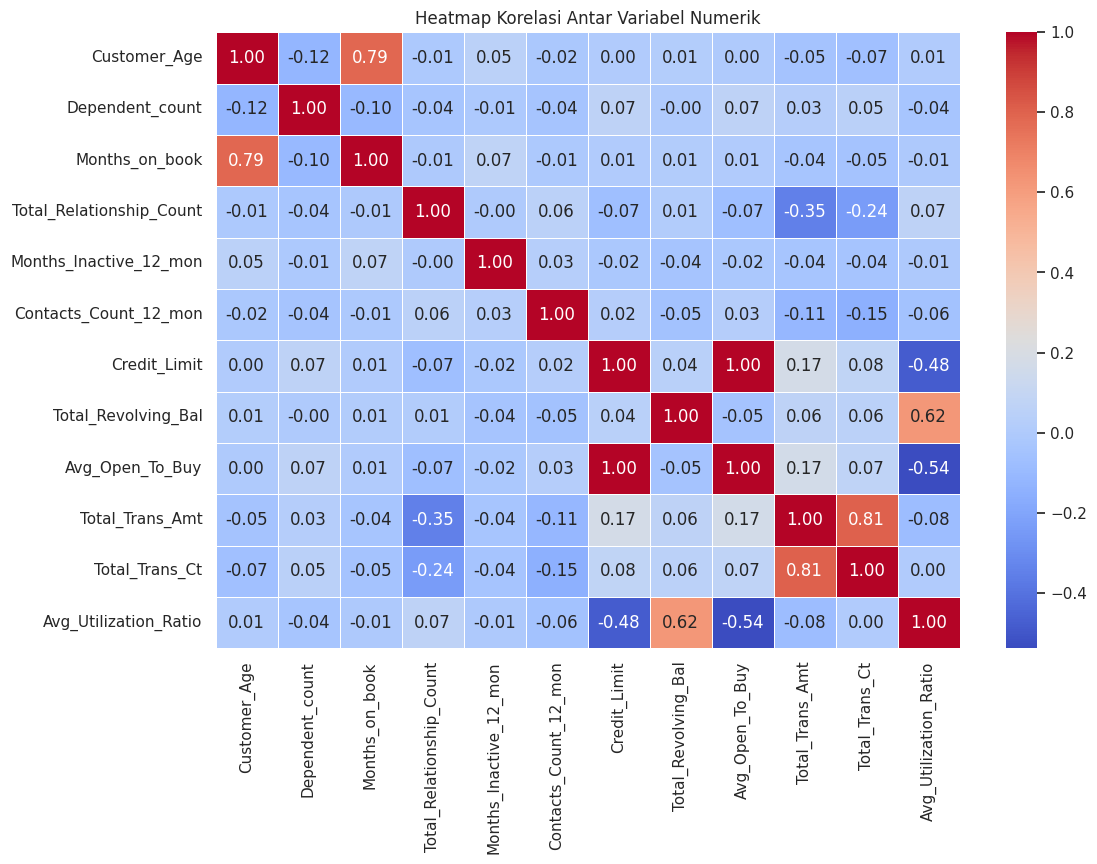

In [29]:
# Memilih beberapa kolom numerik yang relevan untuk korelasi
numeric_cols = [
    'Customer_Age',
    'Dependent_count',
    'Months_on_book',
    'Total_Relationship_Count',
    'Months_Inactive_12_mon',
    'Contacts_Count_12_mon',
    'Credit_Limit',
    'Total_Revolving_Bal',
    'Avg_Open_To_Buy',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Avg_Utilization_Ratio'
]

# Membuat matriks korelasi
corr_matrix = df[numeric_cols].corr()

# Membuat heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

**Insight Visualisasi 8:**  
Heatmap menunjukkan beberapa hubungan korelasi yang kuat. Korelasi paling tinggi terlihat antara **Credit_Limit** dan **Avg_Open_To_Buy** dengan nilai sekitar **0,996**, karena rata-rata open-to-buy sangat berkaitan dengan batas kredit yang tersedia. Selain itu, **Total_Trans_Amt** dan **Total_Trans_Ct** memiliki korelasi positif kuat sekitar **0,807**, yang menunjukkan bahwa jumlah transaksi berhubungan erat dengan total nilai transaksi. **Customer_Age** dan **Months_on_book** juga memiliki korelasi positif sekitar **0,789**, artinya semakin tua usia nasabah, cenderung semakin lama pula hubungan nasabah dengan bank.

# Kesimpulan Umum

Berdasarkan seluruh visualisasi, dataset didominasi oleh nasabah yang masih aktif, dengan proporsi attrited customer sekitar 16%. Mayoritas nasabah berada pada rentang usia dewasa menengah, terutama sekitar 40–50 tahun. Distribusi gender relatif seimbang, meskipun jumlah perempuan sedikit lebih banyak. Dari sisi pendidikan, kategori Graduate menjadi kelompok terbesar, sedangkan dari sisi pendapatan, kategori Less than $40K menjadi kelompok paling dominan.

Visualisasi lanjutan menunjukkan bahwa gender dapat dibandingkan dengan status attrition untuk melihat pola churn awal. Scatterplot memperlihatkan hubungan positif kuat antara jumlah transaksi dan total nilai transaksi. Heatmap juga menegaskan bahwa beberapa variabel numerik memiliki korelasi kuat, khususnya Credit_Limit dengan Avg_Open_To_Buy, Total_Trans_Amt dengan Total_Trans_Ct, serta Customer_Age dengan Months_on_book.

# Penjelasan Singkat Fungsi Kode

- `pd.read_csv()` digunakan untuk membaca file CSV.
- `df.head()` digunakan untuk menampilkan lima baris pertama dataset.
- `df.info()` digunakan untuk melihat tipe data dan jumlah data non-null.
- `df.isnull().sum()` digunakan untuk mengecek missing value.
- `value_counts()` digunakan untuk menghitung jumlah data pada setiap kategori.
- `plt.pie()` digunakan untuk membuat pie chart dan donut chart.
- `plt.bar()` digunakan untuk membuat vertical bar chart.
- `plt.barh()` digunakan untuk membuat horizontal bar chart.
- `plt.hist()` digunakan untuk membuat histogram.
- `sns.countplot()` digunakan untuk membuat grafik jumlah data berdasarkan satu kategori dan kategori pembanding.
- `sns.scatterplot()` digunakan untuk melihat hubungan antara dua variabel numerik.
- `df.corr()` digunakan untuk menghitung korelasi antar variabel numerik.
- `sns.heatmap()` digunakan untuk menampilkan korelasi dalam bentuk matriks warna.